<a href="https://colab.research.google.com/github/poojakatkadesybsc2022-dev/Data_Analysis/blob/main/DataCleanin_Hospital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
df = pd.read_csv("/content/Hospital_Patient_Data.csv")

# display table
print(df.head())

# dataset info
print(df.info())

# stats info
print(df.describe())



  Patient_ID   Name   Age Gender   Department Doctor_Name Admission_Date  \
0      P0001  Pooja  48.0      M  Orthopedics   Dr. Patil     09-04-2024   
1      P0002  Rahul   NaN      F   Cardiology   Dr. Singh     09-08-2024   
2      P0003  Pooja   NaN      M    Neurology    Dr. Khan     29-09-2024   
3      P0004  Rohan  52.0      F   Cardiology     Dr. Rao     08-06-2024   
4      P0005  Kiran  56.0      M     Oncology   Dr. Patil     13-06-2024   

  Discharge_Date       Diagnosis  Treatment_Cost Payment_Mode Room_Type  \
0     13-04-2024          Cancer               0         UPI    General   
1     17-08-2024   Heart Disease           89123         Cash   Private   
2     08-10-2024  Skin Infection               0          UPI   Generel   
3     17-06-2024             NaN           14448    Insurance   Private   
4     14-06-2024             NaN           84306          UPI   Private   

         City Feedback  
0    Kolhapur   averge  
1  Aurangabad      NaN  
2      Nagpur    

In [3]:
# data cleaning

df.isnull().sum()

,0
Patient_ID,0
Name,0
Age,456
Gender,0
Department,0
Doctor_Name,0
Admission_Date,0
Discharge_Date,0
Diagnosis,466
Treatment_Cost,0


In [53]:
df['Age'] = df['Age'].fillna(df['Age'].median())

# Correcting typos in 'Diagnosis' before filling. Note: mean() won't work for strings.
# Let's fill Diagnosis with mode instead of mean as it's a categorical column
df['Diagnosis'] = df['Diagnosis'].fillna(df['Diagnosis'].mode()[0]) # Use mode()[0] to get the first mode if multiple exist

# Standardize feedback categories and then fill missing values
df['Feedback'] = df['Feedback'].replace({'averge': 'Average', 'good': 'Good'})
df['Feedback'] = df['Feedback'].fillna("Average")

# Standardize 'Gender' categories
df['Gender'] = df['Gender'].replace({
    'M': 'Male',
    'F': 'Female',
    'Femael': 'Female' # Correcting typo 'Femael' to 'Female'
})

In [6]:
df.head()

,Patient_ID,Name,Age,Gender,Department,Doctor_Name,Admission_Date,Discharge_Date,Diagnosis,Treatment_Cost,Payment_Mode,Room_Type,City,Feedback
0,P0001,Pooja,48.0,M,Orthopedics,Dr. Patil,09-04-2024,13-04-2024,Cancer,0,UPI,General,Kolhapur,averge
1,P0002,Rahul,46.0,F,Cardiology,Dr. Singh,09-08-2024,17-08-2024,Heart Disease,89123,Cash,Private,Aurangabad,Average
2,P0003,Pooja,46.0,M,Neurology,Dr. Khan,29-09-2024,08-10-2024,Skin Infection,0,UPI,Generel,Nagpur,good
3,P0004,Rohan,52.0,F,Cardiology,Dr. Rao,08-06-2024,17-06-2024,NaN,14448,Insurance,Private,Nagpur,good
4,P0005,Kiran,56.0,M,Oncology,Dr. Patil,13-06-2024,14-06-2024,NaN,84306,UPI,Private,Solapur,Average


In [7]:
df.isnull().sum()

,0
Patient_ID,0
Name,0
Age,0
Gender,0
Department,0
Doctor_Name,0
Admission_Date,0
Discharge_Date,0
Diagnosis,466
Treatment_Cost,0


In [14]:
df['Diagnosis'] = df['Diagnosis'].fillna(df['Diagnosis'].mean())
print(df['Diagnosis'])

TypeError: can only concatenate str (not "int") to str

In [9]:
df.isnull().sum()

,0
Patient_ID,0
Name,0
Age,0
Gender,0
Department,0
Doctor_Name,0
Admission_Date,0
Discharge_Date,0
Diagnosis,466
Treatment_Cost,0


In [16]:
# Remove Duplicates

df = df.drop_duplicates()
print(df)

    Patient_ID   Name   Age  Gender   Department Doctor_Name Admission_Date  \
0        P0001  Pooja  48.0       M  Orthopedics   Dr. Patil     09-04-2024   
1        P0002  Rahul  46.0       F   Cardiology   Dr. Singh     09-08-2024   
2        P0003  Pooja  46.0       M    Neurology    Dr. Khan     29-09-2024   
3        P0004  Rohan  52.0       F   Cardiology     Dr. Rao     08-06-2024   
4        P0005  Kiran  56.0       M     Oncology   Dr. Patil     13-06-2024   
..         ...    ...   ...     ...          ...         ...            ...   
945      P0946  Sneha  46.0    Male     Oncology     Dr. Rao     13-09-2024   
946      P0947   Neha  46.0    Male  Dermatology   Dr. Mehta     05-10-2024   
947      P0948  Rohan  46.0  Female  Orthopedics   Dr. Mehta     25-02-2024   
948      P0949  Priya  83.0    Male   Cardiology   Dr. Singh     16-03-2024   
949      P0950  Rohan  66.0  Femael   Pediatrics     Dr. Rao     29-07-2024   

    Discharge_Date       Diagnosis  Treatment_Cost 

In [22]:
# correct typos

df['Gender'] = df['Gender'].replace({'M':'Male',
                                     'Male':'Male',
                                     'F':'Female',
                                     'female':'Female',
                                     'Female':'Female'})
print(df['Gender'])

0        Male
1      Female
2        Male
3      Female
4        Male
        ...  
945      Male
946      Male
947    Female
948      Male
949    Femael
Name: Gender, Length: 950, dtype: object


In [23]:
print(df['Room_Type'].str.strip())

0      General
1      Private
2      Generel
3      Private
4      Private
        ...   
945    General
946    Private
947       semi
948    Generel
949    Private
Name: Room_Type, Length: 950, dtype: object


DATA **ANALYSIS**

In [10]:
import pandas as pd
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'], dayfirst=True)
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'], dayfirst=True)

print(df['Admission_Date'].head())
print(df['Discharge_Date'].head())

0   2024-04-09
1   2024-08-09
2   2024-09-29
3   2024-06-08
4   2024-06-13
Name: Admission_Date, dtype: datetime64[ns]
0   2024-04-13
1   2024-08-17
2   2024-10-08
3   2024-06-17
4   2024-06-14
Name: Discharge_Date, dtype: datetime64[ns]


In [11]:
df['Length of stay']= (df['Discharge_Date'] - df['Admission_Date']).dt.days
print(df['Length of stay'].head())

0    4
1    8
2    9
3    9
4    1
Name: Length of stay, dtype: int64


In [13]:
# Longest stay top 5 patients

df.nlargest(5,'Length of stay')

,Patient_ID,Name,Age,Gender,Department,Doctor_Name,Admission_Date,Discharge_Date,Diagnosis,Treatment_Cost,Payment_Mode,Room_Type,City,Feedback,Length of stay
21,P0022,Rohan,NaN,F,Neurology,Dr. Sharma,2024-08-27,2024-09-06,Fever,999999,UPI,Generel,Nashik,averge,10
36,P0037,Anjali,NaN,Female,Pediatrics,Dr. Rao,2024-05-01,2024-05-11,NaN,0,Insurance,Generel,Solapur,good,10
37,P0038,Amit,5.0,Female,Oncology,Dr. Patil,2024-08-16,2024-08-26,Heart Disease,999999,INSURANCE,Semi,Kolhapur,good,10
48,P0049,Neha,NaN,Femael,Dermatology,Dr. Sharma,2024-09-22,2024-10-02,Fracture,999999,INSURANCE,Private,Kolhapur,averge,10
63,P0064,Anjali,3.0,Female,Orthopedics,Dr. Rao,2024-05-26,2024-06-05,NaN,89495,Cashh,Semi,Nagpur,good,10


In [15]:
# shortest day top 5 patients

df.nsmallest(5,'Length of stay')

,Patient_ID,Name,Age,Gender,Department,Doctor_Name,Admission_Date,Discharge_Date,Diagnosis,Treatment_Cost,Payment_Mode,Room_Type,City,Feedback,Length of stay
4,P0005,Kiran,56.0,M,Oncology,Dr. Patil,2024-06-13,2024-06-14,NaN,84306,UPI,Private,Solapur,NaN,1
8,P0009,Vikas,33.0,Femael,Cardiology,Dr. Patil,2024-04-18,2024-04-19,Fever,999999,Insurance,Generel,Kolhapur,NaN,1
22,P0023,Vikas,NaN,Female,Orthopedics,Dr. Mehta,2024-10-10,2024-10-11,Heart Disease,131690,UPI,General,Kolhapur,Good,1
25,P0026,Kiran,62.0,Femael,Cardiology,Dr. Sharma,2024-05-20,2024-05-21,NaN,999999,UPI,General,Aurangabad,Poor,1
50,P0051,Kiran,NaN,M,Neurology,Dr. Sharma,2024-04-17,2024-04-18,NaN,0,INSURANCE,semi,Aurangabad,NaN,1


**DEPARTMENT** **ANALYSIS**

In [21]:
# PATIENT COUNT

df.groupby('Department')['Patient_ID'].count()

# TOTAL REVENUE

department_revenue = df.groupby('Department')['Treatment_Cost'].sum()
print(department_revenue)

# AVERAGE COST
df.groupby('Department')['Treatment_Cost'].mean()

# MOST PROFITABLE DEPARTMENT
#department_revenue.idxmax()

# LEAST PROFITABLE
#department_revenue.idxmin()

Department
Cardiology     65078383
Dermatology    44528915
Neurology      67945335
Oncology       50330226
Orthopedics    46235182
Pediatrics     52744479
Name: Treatment_Cost, dtype: int64


,Treatment_Cost
Department,
Cardiology,369763.539773
Dermatology,280056.069182
Neurology,383871.949153
Oncology,314563.912500
Orthopedics,304178.828947
Pediatrics,361263.554795


In [25]:
# MOST PROFITABLE DEPARTMENT
most_profitable_department = department_revenue.idxmax()
most_profitable_revenue = department_revenue.max()
print("Most Profitable Department:")
print("Department:", most_profitable_department)
print("Total Revenue:", most_profitable_revenue)

Most Profitable Department:
Department: Neurology
Total Revenue: 67945335


In [26]:
# LEAST PROFITABLE
least_profitable_department = department_revenue.idxmin()
least_profitable_revenue = department_revenue.min()
print("Least Profitable Department:")
print("Department:", least_profitable_department)
print("Total Revenue:", least_profitable_revenue)

Least Profitable Department:
Department: Dermatology
Total Revenue: 44528915


**DOCTORS** **PERFORMANCE**

In [30]:
# DOCTOR WITH MAXIMUM Patient

doctor_patient = df.groupby('Doctor_Name')['Patient_ID'].count()
doctor_patient.sort_values(ascending=False)

#sort_values(ascending=False) arranges
#these counts from highest to lowest

,Patient_ID
Doctor_Name,
Dr. Rao,185
Dr. Patil,169
Dr. Singh,165
Dr. Sharma,158
Dr. Mehta,150
Dr. Khan,143


In [32]:
# AVERAGE TREATMENT COST
df.groupby('Doctor_Name')['Treatment_Cost'].mean()

,Treatment_Cost
Doctor_Name,
Dr. Khan,350983.132867
Dr. Mehta,295130.493333
Dr. Patil,293947.011834
Dr. Rao,392512.459459
Dr. Sharma,352405.272152
Dr. Singh,329881.666667


**FEEDBACK ANALYSIS**


In [41]:
# DEPARTMENT WISE FEEDBACK
feedback = pd.crosstab(df['Department'],df['Feedback'])
print(feedback)

Feedback     Average  Good  Poor
Department                      
Cardiology        94    47    35
Dermatology       80    54    25
Neurology         82    72    23
Oncology          88    49    23
Orthopedics       80    43    29
Pediatrics        77    51    18


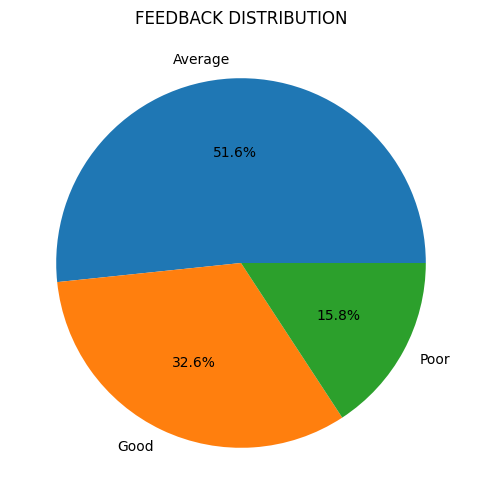

In [40]:
import matplotlib.pyplot as plt
df['Feedback'].value_counts().plot(kind='pie',autopct='%1.1f%%',figsize=(6,6))
plt.title("FEEDBACK DISTRIBUTION")
plt.ylabel("")
plt.show()
# autopct = automatic percentage
#% = start 1.1f= float format and one digit after decimal
#%% = one for percentage sign adn second for to end

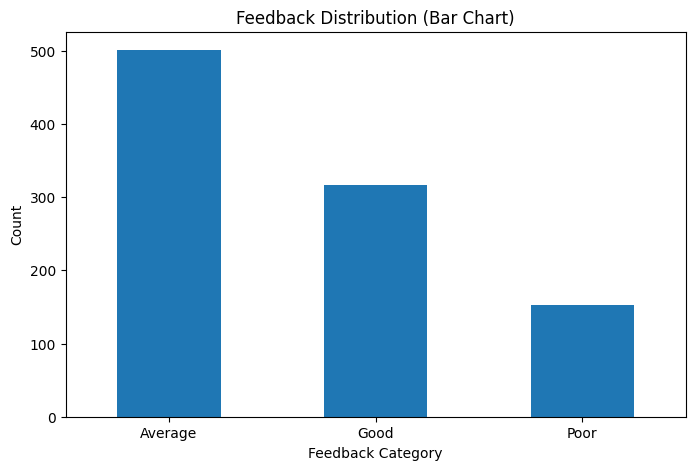

In [55]:
import matplotlib.pyplot as plt

df['Feedback'].value_counts().plot(kind='bar', figsize=(8, 5))
plt.title('Feedback Distribution (Bar Chart)')
plt.xlabel('Feedback Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

 **CITY** **ANALYSIS**

In [42]:
# TOP 5 CITY REVENUE

city_revenue = df.groupby('City')['Treatment_Cost'].sum()
city_revenue.nlargest(5)

,Treatment_Cost
City,
Solapur,55818911
Nagpur,50871672
Kolhapur,50132869
Pune,47814655
Mumbai,43508840


In [44]:
city_revenue.sort_values(ascending=True).head()

,Treatment_Cost
City,
Aurangabad,36479355
Nashik,42236218
Mumbai,43508840
Pune,47814655
Kolhapur,50132869


<function matplotlib.pyplot.show(close=None, block=None)>

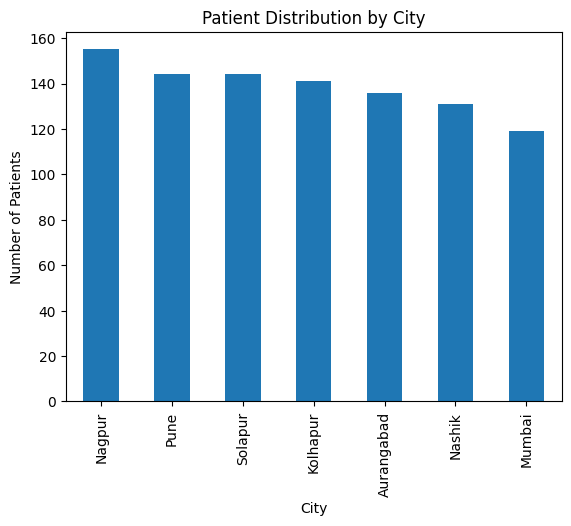

In [45]:
# PATIENT DISTRIBUTION
df['City'].value_counts().plot(kind='bar')
plt.xlabel('City')
plt.ylabel('Number of Patients')
plt.title('Patient Distribution by City')
plt.show

**MONTHLY ADMISSION TREND**


Month
2024-01     91
2024-02     76
2024-03    104
2024-04    101
2024-05     86
2024-06     96
2024-07    110
2024-08     97
2024-09    100
2024-10    109
Freq: M, Name: Patient_ID, dtype: int64


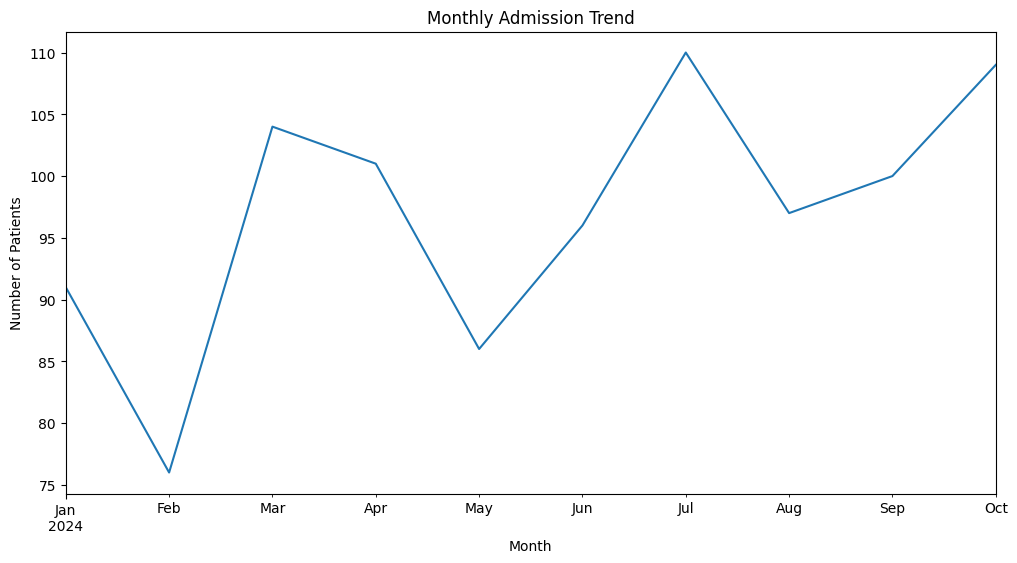

In [48]:
df['Month']= df['Admission_Date'].dt.to_period('M')
monthly = df.groupby('Month')['Patient_ID'].count()
print(monthly)

monthly.plot(kind='line',figsize=(12,6))
plt.xlabel('Month')
plt.ylabel('Number of Patients')
plt.title('Monthly Admission Trend')
plt.show()

**HIGH COST PATIENT**

In [50]:
df.nlargest(5,'Treatment_Cost')

,Patient_ID,Name,Age,Gender,Department,Doctor_Name,Admission_Date,Discharge_Date,Diagnosis,Treatment_Cost,Payment_Mode,Room_Type,City,Feedback,Length of stay,Month
8,P0009,Vikas,33.0,Femael,Cardiology,Dr. Patil,2024-04-18,2024-04-19,Fever,999999,Insurance,Generel,Kolhapur,Average,1,2024-04
9,P0010,Sneha,2.0,M,Neurology,Dr. Rao,2024-02-27,2024-03-02,Migraine,999999,INSURANCE,Private,Nashik,Good,4,2024-02
10,P0011,Kiran,37.0,M,Pediatrics,Dr. Sharma,2024-06-09,2024-06-11,Fever,999999,UPI,semi,Kolhapur,Average,2,2024-06
14,P0015,Priya,46.0,Femael,Cardiology,Dr. Patil,2024-08-24,2024-08-31,Migraine,999999,INSURANCE,Generel,Nagpur,Average,7,2024-08
16,P0017,Kiran,14.0,Female,Orthopedics,Dr. Rao,2024-08-25,2024-09-03,Fracture,999999,UPI,Private,Aurangabad,Poor,9,2024-08


**SAVE CLENED DATASET**

In [54]:
df.to_csv("Hospital_Cleaned_data.csv",index=False)